<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Generating geometric median composites (geomedians)</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~15 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://explorer.dea.ga.gov.au/ga_ls8c_ard_3">ga_ls8c_ard_3</a>
</div>

<!-- Citing - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📝 Citation</b><br>
    
* Roberts, D., Mueller, N., & Mcintyre, A. (2017). High-dimensional pixel composites from earth observation time series. <i>IEEE Transactions on Geoscience and Remote Sensing</i>, 55(11), 6254–6264. https://doi.org/10.1109/TGRS.2017.2723896

* Roberts, D., Dunn, B., & Mueller, N. (2018). Open data cube products using high-dimensional statistics of time series. <i>IGARSS 2018 - 2018 IEEE International Geoscience and Remote Sensing Symposium</i>, 8647–8650. https://doi.org/10.1109/IGARSS.2018.8518312
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>

## Background

Individual remote sensing images can be affected by noisy data, including clouds, cloud shadows, and haze. 
To produce cleaner images that can be compared more easily across time, we can create 'summary' images or 'composites' that combine multiple images into one image to reveal the median or 'typical' appearance of the landscape for a certain time period. 

One approach is to create a [geomedian](https://github.com/daleroberts/hdmedians). 
A `geomedian` is based on a high-dimensional statistic called the 'geometric median' [(Small 1990)](https://www.jstor.org/stable/1403809), which effectively trades a temporal stack of poor quality observations for a single high-quality pixel composite with reduced spatial noise [(Roberts et al. 2017)](https://ieeexplore.ieee.org/abstract/document/8004469). 
In contrast to a standard median, a geomedian maintains the relationship between spectral bands. 
This allows us to conduct further analysis on the composite images just as we would on the original satellite images (e.g by allowing the calculation of common band indices like NDVI).

## Description
In this notebook we will take of time series of noisy satellite images collected over a year and calculate an annual geomedian composite which is largely free of clouds and other noisy data.

Geomedian computations are expensive in terms of memory, data bandwidth, and cpu usage. 
The ODC has some useful functions, [geomedian](https://github.com/opendatacube/datacube-stats/blob/master/datacube_stats/statistics/geomedian.py) that allow [dask](https://docs.dask.org/en/latest/) to perform the computation in parallel across many threads to speed things up. 
In this notebook a local dask cluster is used, but the same approach should work using a larger, distributed dask cluster.

***


## Getting started
To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages

In [1]:
%matplotlib inline

import numpy as np
import odc.stac
from odc.algo import (
    to_f32,
    xr_geomedian,
    int_geomedian,
    fmask_to_bool,
    enum_to_bool,
    mask_cleanup,
    erase_bad,
)
from odc.geo import BoundingBox
import pystac_client
import warnings

warnings.filterwarnings("ignore")

from dea_tools.plotting import rgb
from dea_tools.dask import create_local_dask_cluster
from dea_tools.datahandling import stac_assets, stac_collections

### Set up a dask cluster

This will help keep our memory use down and conduct the analysis in parallel. If you'd like to view the `dask dashboard`, click on the hyperlink that prints below the cell. You can use the dashboard to monitor the progress of calculations.


In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/amir.rastar@ga.gov.au/proxy/35097/status,
Dashboard: /user/amir.rastar@ga.gov.au/proxy/35097/status,Workers: 1
Total threads: 64,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37097,Workers: 0
Dashboard: /user/amir.rastar@ga.gov.au/proxy/35097/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41869,Total threads: 64
Dashboard: /user/amir.rastar@ga.gov.au/proxy/43347/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:35443,


### Connect to DEA's STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) or [Loading data with STAC notebook](../Beginners_guide/04a_Loading_data_STAC.ipynb) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access` but since we are launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [3]:
# Connect to DEA STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

We can use `dea_tools` `stac_collections` functionality to inspect the products that are available. The table below shows the product names that we will use to load the data and a brief description.

In [4]:
stac_collections(catalog=catalog, products=["ga_ls8c_ard_3"])

,description,bbox,start_date,end_date,license
product,,,,,
ga_ls8c_ard_3,Geoscience Australia Landsat 8 Operational Lan...,"70.26, -57.00, 169.59, -7.63",2013-03-19,2025-12-10,CC-BY-4.0


We can further inspect the data available for GeoMAD using the `stac_assets` functionality. The table below lists each of the bands available in `ga_ls8c_ard_3` data product.

In [5]:
stac_assets(catalog, products="ga_ls8c_ard_3")

roles                  band_names  \
product       asset                                                          
ga_ls8c_ard_3 oa_fmask                    data                    oa_fmask   
              nbart_nir                   data                   nbart_nir   
              nbart_red                   data                   nbart_red   
              nbart_blue                  data                  nbart_blue   
              nbart_green                 data                 nbart_green   
              nbart_swir_1                data                nbart_swir_1   
              nbart_swir_2                data                nbart_swir_2   
              oa_time_delta               data               oa_time_delta   
              oa_solar_zenith             data             oa_solar_zenith   
              oa_exiting_angle            data            oa_exiting_angle   
              oa_solar_azimuth            data            oa_solar_azimuth   
              oa_incident_angle           data           oa_incident_angle   
              oa_relative_slope           data           oa_relative_slope   
              oa_satellite_view           data           oa_satellite_view   
              nbart_panchromatic          data          nbart_panchromatic   
              oa_nbart_contiguity         data         oa_nbart_contiguity   
              oa_relative_azimuth         data         oa_relative_azimuth   
              oa_azimuthal_exiting        data        oa_azimuthal_exiting   
              oa_satellite_azimuth        data        oa_satellite_azimuth   
              nbart_coastal_aerosol       data       nbart_coastal_aerosol   
              oa_azimuthal_incident       data       oa_azimuthal_incident   
              oa_combined_terrain_shadow  data  oa_combined_terrain_shadow   

                                         nodata dtype  
product       asset                                    
ga_ls8c_ard_3 oa_fmask                                 
              nbart_nir                                
              nbart_red                                
              nbart_blue                               
              nbart_green                              
              nbart_swir_1                             
              nbart_swir_2                             
              oa_time_delta                            
              oa_solar_zenith                          
              oa_exiting_angle                         
              oa_solar_azimuth                         
              oa_incident_angle                        
              oa_relative_slope                        
              oa_satellite_view                        
              nbart_panchromatic                       
              oa_nbart_contiguity                      
              oa_relative_azimuth                      
              oa_azimuthal_exiting                     
              oa_satellite_azimuth                     
              nbart_coastal_aerosol                    
              oa_azimuthal_incident                    
              oa_combined_terrain_shadow

## Load Landsat 8 using odc stac

Here we are loading in a timeseries of cloud-masked Landsat 8 satellite images through the odc stac using `odc.stac.load` function. 
This will provide us with some data to work with. To limit computation and memory this example uses only three optical bands (red, green, blue).
First we query the item using `pystac_client`.

In [6]:
# Set up centre of area of interest, and area to buffer coordinates by
lat, lon = -12.25, 132.40
buffer = 0.07

bbox = BoundingBox(
    left=lon - buffer,
    bottom=lat - buffer,
    right=lon + buffer,
    top=lat + buffer,
)
date = "2018"

query = catalog.search(
    collections="ga_ls8c_ard_3",
    datetime=date,
    bbox=bbox,
)

items = list(query.items())

print(f"Found {len(items)} items")

Found 69 items


Compared to the typical use of `odc.stac.load` which by default returns data with floating point numbers containing `NaN` (i.e. `float32`), in this example we will set the `dtype` to  `Int16`. 
This will keep our data in its original integer data type (i.e. `Int16`), with nodata values marked with `-999`.
Doing this will halve the amount of memory our data takes up, which can be extremely valuable when conducting large-scale analyses.

In [7]:
# Load available data
ds = odc.stac.load(
    items,
    bands=["nbart_green", "nbart_red", "nbart_blue", "oa_fmask"],
    chunks={"x": 2000, "y": 2000},
    bbox=bbox,
    dtype="int16",
    resolution=30,
    groupby="solar_day",
    crs="EPSG:3577",
    nodata=-999,
)

ds

<xarray.Dataset> Size: 97MB
Dimensions:      (y: 509, x: 520, time: 46)
Coordinates:
  * y            (y) float64 4kB -1.284e+06 -1.284e+06 ... -1.299e+06 -1.299e+06
  * x            (x) float64 4kB 3.656e+04 3.658e+04 ... 5.21e+04 5.212e+04
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 368B 2018-01-04T01:16:45.169839 ... 20...
Data variables:
    nbart_green  (time, y, x) int16 24MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>
    nbart_red    (time, y, x) int16 24MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>
    nbart_blue   (time, y, x) int16 24MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>
    oa_fmask     (time, y, x) int16 24MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>

### Applying the cloud mask from Landsat data

In [8]:
ds.oa_fmask.attrs = {
    "nodata": 0,
    "flags_definition": {
        "qa": {
            "values": {
                "0": "null",
                "1": "clear",
                "2": "cloud",
                "3": "cloud shadows",
                "4": "snow",
                "5": "water",
            }
        }
    },
    "crs": "EPSG:3577",
    "grid_mapping": "spatial_ref",
}
mask = fmask_to_bool(ds.oa_fmask, categories=("cloud", "cloud shadows")) 
ds = erase_bad(ds, where=mask)
ds = ds.drop_vars("oa_fmask")

## Plot timesteps in true colour

To visualise the data, use the pre-loaded `rgb` utility function to plot a true colour image for a series of timesteps. 
Black areas indicate where clouds or other invalid pixels in the image have been set to `-999` to indicate no data.

The code below will plot three timesteps of the time series we just loaded.

> **Note:** This step can be quite slow because the dask arrays being plotted must be computed first.

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


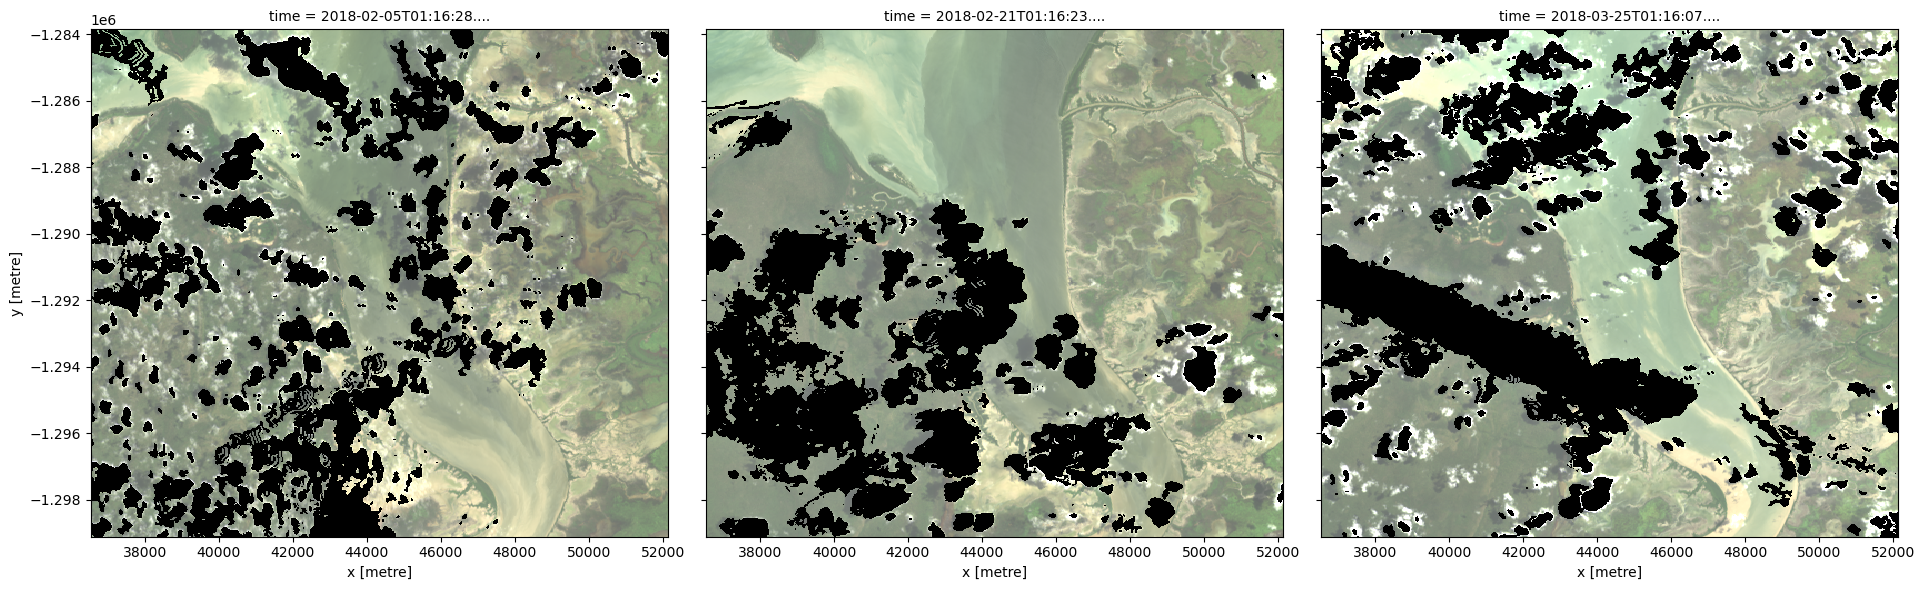

In [9]:
# Set the timesteps to visualise
timesteps = [4, 6, 10]

# Generate RGB plots at each timestep
rgb(ds, index=timesteps)

## Generate a geomedian

As you can see above, most satellite images will have at least some areas masked out due to clouds or other interference between the satellite and the ground. 
Running the `int_geomedian` function will generate a geomedian composite by combining all the observations in our `xarray.Dataset` into a single, complete (or near complete) image representing the geometric median of the time period.

> **Note:** Because our data was lazily loaded with `dask`, the geomedian algorithm itself will not be triggered until we call the `.compute()` method in the next step.

In [10]:
geomedian = int_geomedian(ds)

### Run the computation

The `.compute()` method will trigger the computation of the geomedian algorithm above.
This will take about a few minutes to run; view the `dask dashboard` to check the progress.

In [11]:
%%time
geomedian = geomedian.compute()

CPU times: user 2.13 s, sys: 132 ms, total: 2.26 s
Wall time: 1min 54s


If we print our result, you will see that the `time` dimension has now been removed and we are left with a single image that represents the geometric median of all the satellite images in our initial time series:

In [12]:
geomedian

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 509, x: 520)
Coordinates:
  * y            (y) float64 4kB -1.284e+06 -1.284e+06 ... -1.299e+06 -1.299e+06
  * x            (x) float64 4kB 3.656e+04 3.658e+04 ... 5.21e+04 5.212e+04
Data variables:
    nbart_green  (y, x) int16 529kB 1353 1377 1372 1353 ... 1059 1064 1030 1026
    nbart_red    (y, x) int16 529kB 930 961 951 919 915 ... 1365 1381 1338 1320
    nbart_blue   (y, x) int16 529kB 1065 1091 1089 1072 1072 ... 756 758 737 734

### Plot the geomedian composite

Plotting the result, we can see that the geomedian image is much more complete than any of the individual images. 
We can also use this data in downstream analysis as the relationships between the spectral bands are maintained by the geometric median statistic.


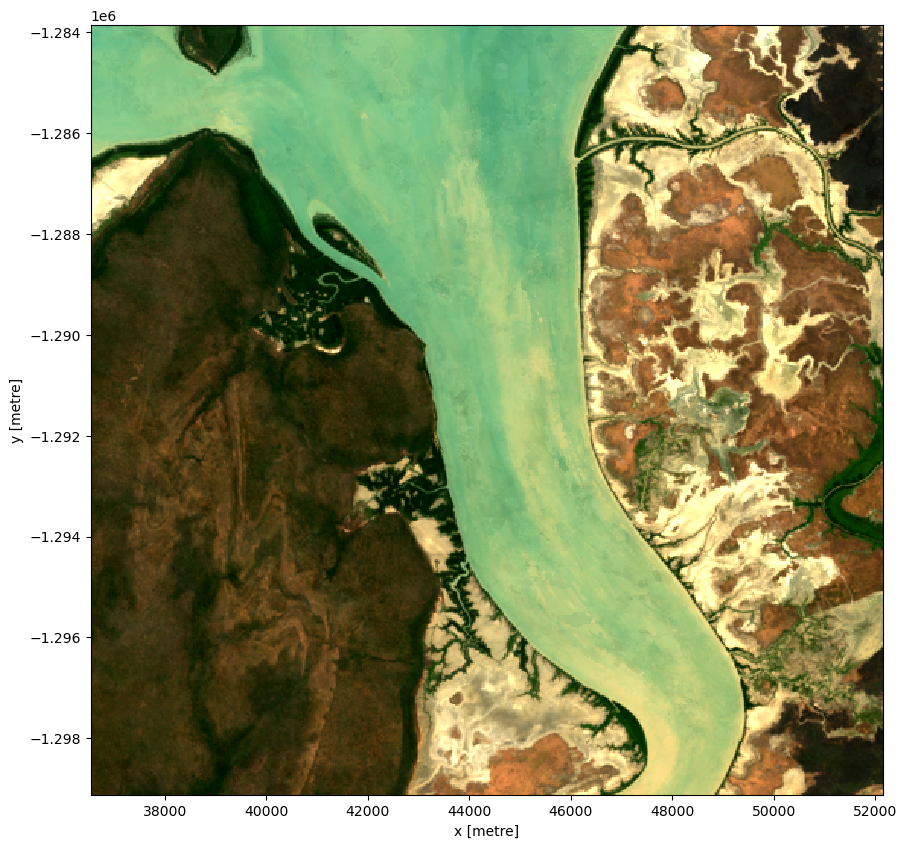

In [13]:
# Plot the result
rgb(geomedian, size=10)

## Running geomedian on grouped or resampled timeseries

In the notebook [Generating composites](./Generating_composites.ipynb), built in functions such as `mean` and `median` are run on timeseries data that has been resampled or grouped.  
We can use the same techniques with the geomedian function.

#### Resampling 

First we will split the timeseries into the desired groups.
Resampling can be used to create a new set of times at regular intervals:

 * `grouped = da_scaled.resample(time=1M)`
 
    * `'nD'` - number of days (e.g. `'7D'` for seven days)
    * `'nM'` - number of months (e.g. `'6M'` for six months)
    * `'nY'` - number of years (e.g. `'2Y'` for two years)

#### Group By
Grouping works by looking at part of the date, but ignoring other parts. 
For instance, `'time.month'` would group together all January data together, no matter what year it is from.

 * `grouped = da_scaled.groupby('time.month')`
 
     * `'time.day'` - groups by the day of the month (1-31)
     * `'time.dayofyear'` - groups by the day of the year (1-365)
     * `'time.week'` - groups by week (1-52) 
     * `'time.month'` - groups by the month (1-12)
     * `'time.season'` - groups into 3-month seasons:
         - `'DJF'` December, January, February
         - `'MAM'` March, April, May
         - `'JJA'` June, July, August
         - `'SON'` September, October, November
     * `'time.year'` - groups by the year
 
Here we will resample into three four-monthly groups (`'4M'`), with the group starting at the start of the month (represented by the `'S'` at the end).

In [14]:
grouped = ds.resample(time="4MS")
grouped

<DatasetResample, grouped over 1 grouper(s), 3 groups in total:
    '__resample_dim__': TimeResampler('__resample_dim__'), 3/3 groups with labels 2018-01-01, ..., 2018-09-01>

Now we will apply the `int_geomedian` function to each resampled group using the `map` method.

Instead of calling `int_geomedian(ds)` on the entire array, we pass the `int_geomedian` function to `map` to apply it separately to each resampled group.

In [15]:
geomedian_grouped = grouped.map(int_geomedian)

We can now trigger the computation, and watch progress using the dask dashboard.

In [16]:
%%time
geomedian_grouped = geomedian_grouped.compute()

CPU times: user 3.79 s, sys: 223 ms, total: 4.01 s
Wall time: 3min 46s


We can plot the output geomedians, and see the change in the landscape over the year:

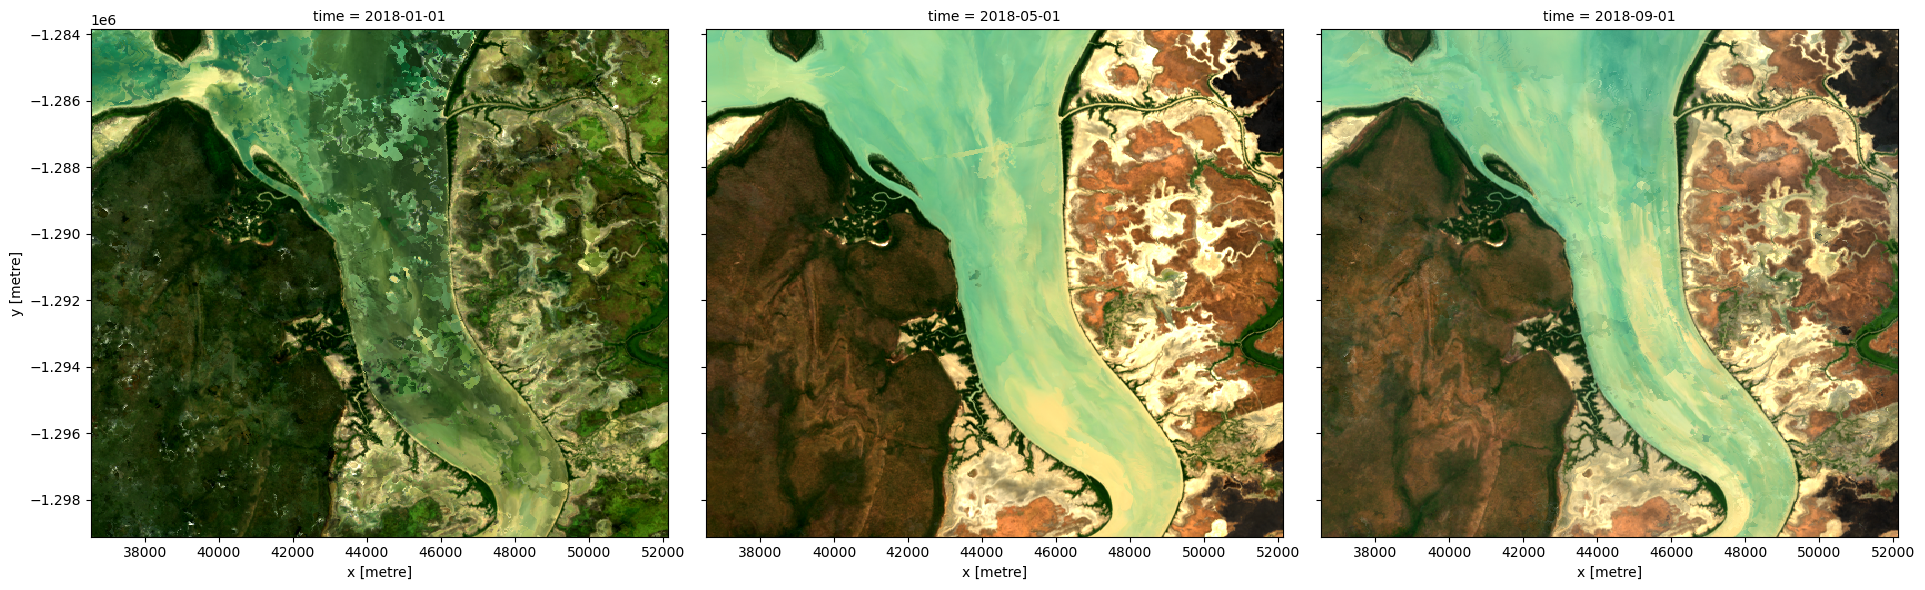

In [17]:
rgb(geomedian_grouped, col="time", col_wrap=4)

## Advanced: Geomedian on float arrays

The ODC has a useful function, [geomedian](https://github.com/opendatacube/datacube-stats/blob/master/datacube_stats/statistics/geomedian.py) that allows for calcuating geomedians on a `xarray.Dataset` (as well as `xr.DataArrays` and `numpy` arrays) with a `float` datatype.

To demonstrate this we will reload our dataset using `load_ard`, but this time not set `dtype='native'`. 
This will return our dataset in dtype `Float32`.

In [18]:
# Load available data
ds = odc.stac.load(
    items,
    bands=["nbart_green", "nbart_red", "nbart_blue"],
    chunks={"x": 2000, "y": 2000},
    bbox=bbox,
    resolution=30,
    groupby="solar_day",
    crs="EPSG:3577",
)

# Print output data
ds

<xarray.Dataset> Size: 146MB
Dimensions:      (y: 509, x: 520, time: 46)
Coordinates:
  * y            (y) float64 4kB -1.284e+06 -1.284e+06 ... -1.299e+06 -1.299e+06
  * x            (x) float64 4kB 3.656e+04 3.658e+04 ... 5.21e+04 5.212e+04
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 368B 2018-01-04T01:16:45.169839 ... 20...
Data variables:
    nbart_green  (time, y, x) float32 49MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>
    nbart_red    (time, y, x) float32 49MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>
    nbart_blue   (time, y, x) float32 49MB dask.array<chunksize=(1, 509, 520), meta=np.ndarray>

Doing Cloud masking again.

In [19]:
ds = erase_bad(ds, where=mask)

**Note**: `xr_geomedian` has several parameters we can set that will control its functionality: 

* Setting `num_thread=1` will disable the internal threading and instead allow parallelisation with `dask`.  
The `eps` parameter controls the number of iterations to conduct; a good default is `1e-7.`  

* For numerical stability, it can also be advisable to scale surface reflectance float values in the dataset to 0-1 (instead of 0-10,000 as is the default for LS8). 
We can do this by using the helper functions `to_f32`. 
We do this in the code cell below before we compute the geomedian. Note, this is not an essential step.
    

In [20]:
# Scale the values using the f_32 util function
sr_max_value = 10000  # maximum SR value in the loaded product
scale, offset = (
    1 / sr_max_value,
    0,
)  # differs per product, aim for 0-1 values in float32
ds_scaled = to_f32(ds, scale=scale, offset=offset)

In [ ]:
geomedian = xr_geomedian(
    ds_scaled,
    num_threads=1,
    eps=1e-7,
).compute()

In [ ]:
rgb(geomedian)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2024

**Compatible datacube version:** 

In [ ]:
print(odc.stac.__version__)

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->